In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

resultado01.pgm: Diferentes: 1886 pixels (93.1358% do total)
resultado01.pgm: Maior diferença: 32
resultado01.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


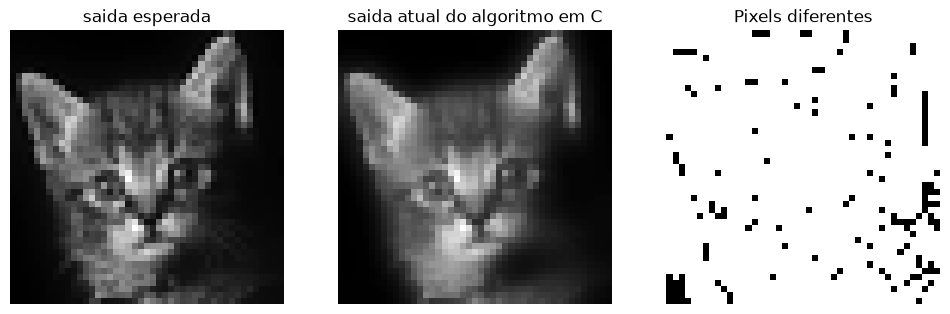

resultado02.pgm: Diferentes: 1919 pixels (94.7654% do total)
resultado02.pgm: Maior diferença: 35
resultado02.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  2]
 [ 0  3]
 [ 0  7]
 [ 0 12]
 [ 0 14]
 [ 0 15]
 [ 0 16]
 [ 0 17]]


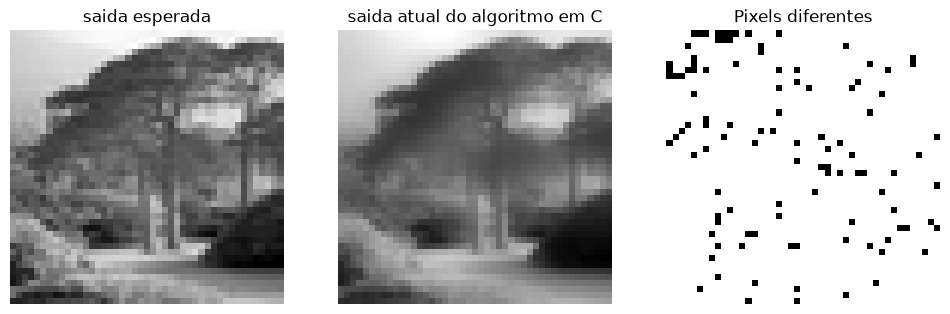

resultado03.pgm: Diferentes: 1870 pixels (92.3457% do total)
resultado03.pgm: Maior diferença: 238
resultado03.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


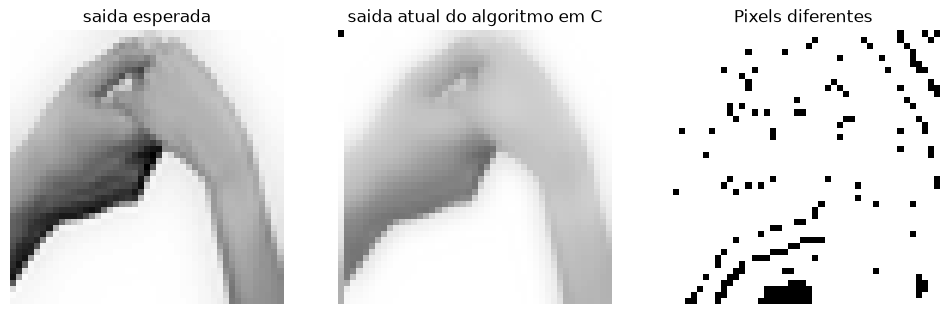

resultado04.pgm: Diferentes: 1859 pixels (91.8025% do total)
resultado04.pgm: Maior diferença: 28
resultado04.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


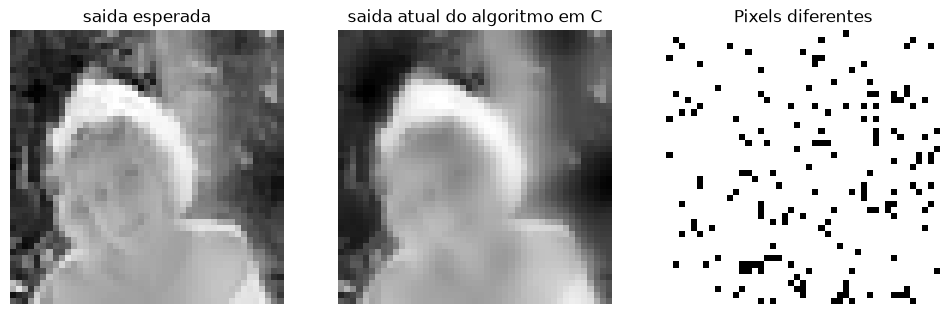

resultado05.pgm: Diferentes: 1768 pixels (87.3086% do total)
resultado05.pgm: Maior diferença: 33
resultado05.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


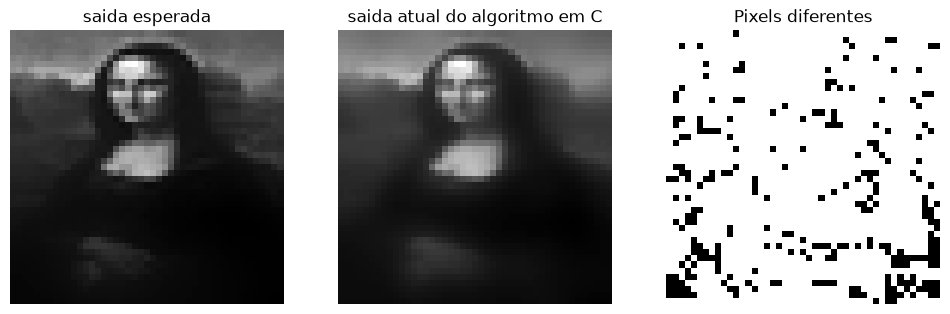

resultado06.pgm: Diferentes: 1661 pixels (82.0247% do total)
resultado06.pgm: Maior diferença: 11
resultado06.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  3]
 [ 0  4]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 11]]


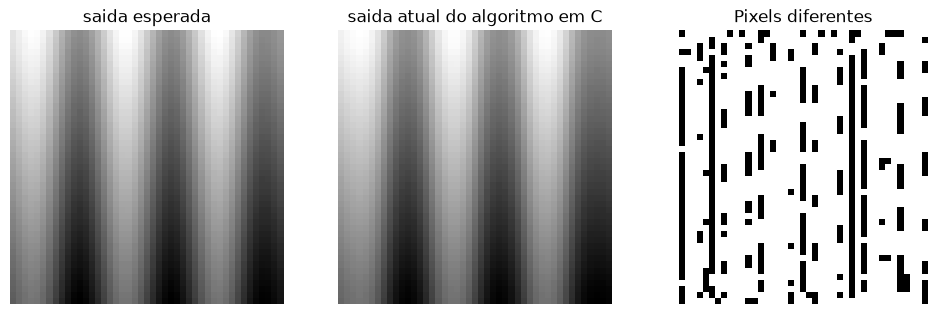

resultado07.pgm: Diferentes: 1944 pixels (96.0000% do total)
resultado07.pgm: Maior diferença: 45
resultado07.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


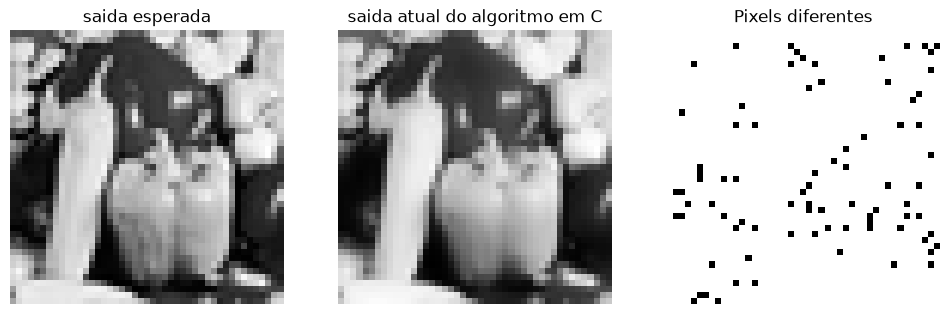

resultado08.pgm: Diferentes: 1811 pixels (89.4321% do total)
resultado08.pgm: Maior diferença: 175
resultado08.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


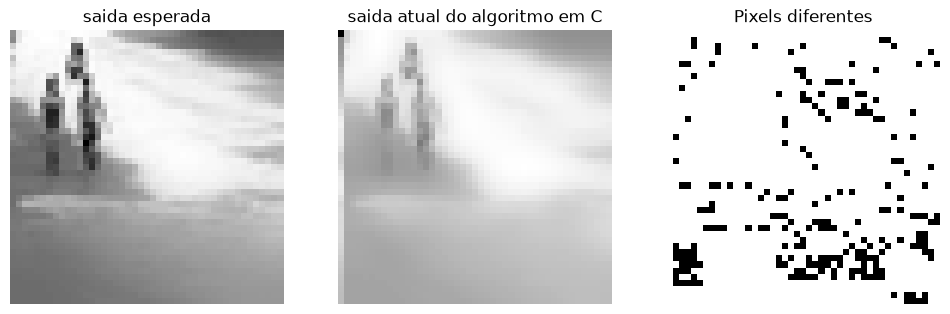

resultado09.pgm: Diferentes: 1810 pixels (89.3827% do total)
resultado09.pgm: Maior diferença: 30
resultado09.pgm: Primeiros pixels diferentes (linha, coluna):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [0 5]
 [0 6]
 [0 7]
 [0 8]
 [0 9]]


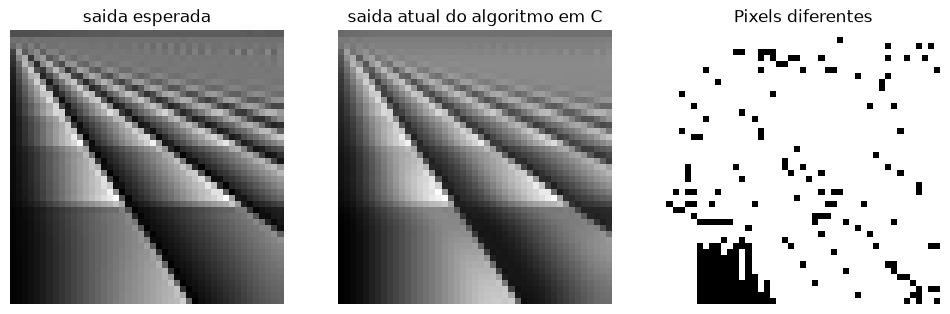

resultado10.pgm: Diferentes: 1866 pixels (92.1481% do total)
resultado10.pgm: Maior diferença: 193
resultado10.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0 10]
 [ 0 11]
 [ 0 12]
 [ 0 13]
 [ 0 14]]


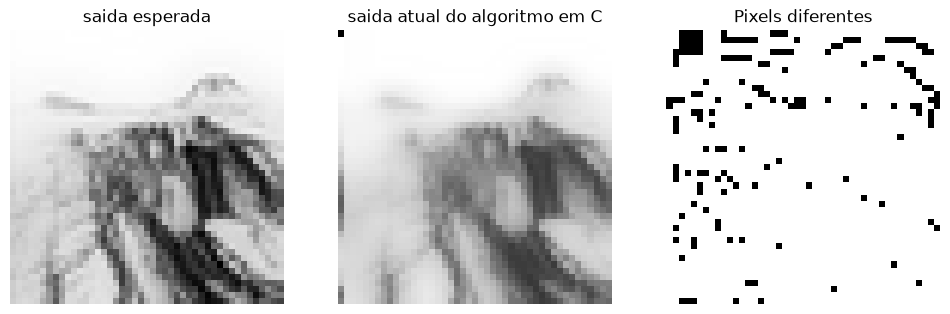

resultado11.pgm: Diferentes: 1821 pixels (89.9259% do total)
resultado11.pgm: Maior diferença: 17
resultado11.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0 12]
 [ 0 13]
 [ 0 14]
 [ 0 15]
 [ 0 16]
 [ 0 17]
 [ 0 18]
 [ 0 19]
 [ 0 20]
 [ 0 21]]


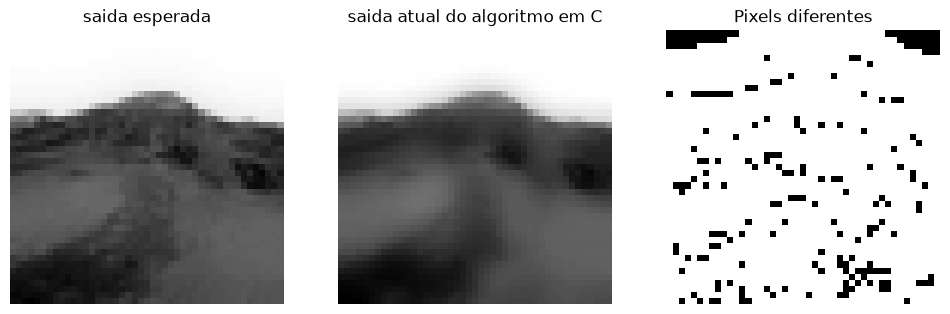

resultado12.pgm: Diferentes: 1791 pixels (88.4444% do total)
resultado12.pgm: Maior diferença: 176
resultado12.pgm: Primeiros pixels diferentes (linha, coluna):
[[ 0  0]
 [ 0  1]
 [ 0  5]
 [ 0  6]
 [ 0  7]
 [ 0  8]
 [ 0  9]
 [ 0 10]
 [ 0 11]
 [ 0 12]]


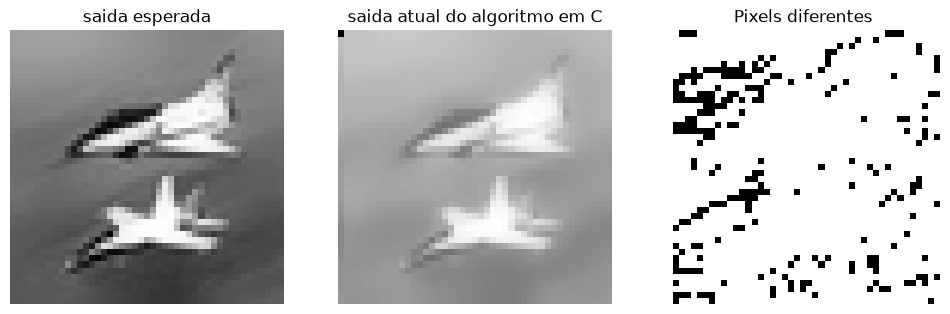

In [2]:
for filename in os.listdir("images_pgm_c_filtradas"):
    if filename.endswith(".pgm"):
        output_actual = cv2.imread(os.path.join("images_pgm_c_filtradas", filename), cv2.IMREAD_GRAYSCALE)
        output_expected = cv2.imread(os.path.join("images_pgm_py_filtradas", filename), cv2.IMREAD_GRAYSCALE)

        if output_expected.shape != output_actual.shape:
            print(f"{filename}: Diferentes: dimensões distintas")
        elif output_expected.dtype != output_actual.dtype:
            print(f"{filename}: Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
        elif np.array_equal(output_expected, output_actual):
            print(f"{filename}: As imagens são idênticas pixel a pixel")
        else:
            mask = output_expected != output_actual
            n_diff = mask.sum()
            print(f"{filename}: Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

            # diferença absoluta em tipo maior, para evitar overflow do uint8
            diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
            print(f"{filename}: Maior diferença:", diff.max())

            coords = np.argwhere(mask)
            print(f"{filename}: Primeiros pixels diferentes (linha, coluna):")
            print(coords[:10])

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(output_expected, cmap="gray"); axes[0].set_title("saida esperada")
        axes[1].imshow(output_actual, cmap="gray"); axes[1].set_title("saida atual do algoritmo em C")
        axes[2].imshow(mask, cmap="gray"); axes[2].set_title("Pixels diferentes")
        for ax in axes:
            ax.axis("off")
        plt.show()

# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)
# output_actual = cv2.imread("images_pgm_c_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

# output_expected = cv2.imread("images_pgm_py_filtradas/resultado01.pgm", cv2.IMREAD_GRAYSCALE)

# if output_expected.shape != output_actual.shape:
#     print("Diferentes: dimensões distintas")
# elif output_expected.dtype != output_actual.dtype:
#     print("Diferentes: tipos de dado distintos (ex.: 8 vs 16 bits)")
# elif np.array_equal(output_expected, output_actual):
#     print("As imagens são idênticas pixel a pixel")
# else:
#     mask = output_expected != output_actual
#     n_diff = mask.sum()
#     print(f"Diferentes: {n_diff} pixels ({100 * n_diff / mask.size:.4f}% do total)")

#     # diferença absoluta em tipo maior, para evitar overflow do uint8
#     diff = np.abs(output_expected.astype(np.int32) - output_actual.astype(np.int32))
#     print("Maior diferença:", diff.max())

#     coords = np.argwhere(mask)
#     print("Primeiros pixels diferentes (linha, coluna):")
#     print(coords[:10])


# fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# axs[0].imshow(output_expected, cmap="gray"); axs[0].set_title("saida esperada")
# axs[1].imshow(output_actual, cmap="gray"); axs[1].set_title("saida atual do algoritmo em C")
# axs[2].imshow(mask, cmap="gray"); axs[2].set_title("Pixels diferentes")
# for ax in axs:
#     ax.axis("off")
# plt.show()